#  Diabetes Prediction using Logistic Regression

---

### 📌 Project Overview

In this project, we will **predict whether a person has diabetes** based on health data like age, BMI, blood glucose level, and more.

| Step | What We Do |
|------|------------|
| 1️⃣ | Import Libraries |
| 2️⃣ | Load & Understand the Data |
| 3️⃣ | Exploratory Data Analysis (EDA) |
| 4️⃣ | Prepare Data for ML |
| 5️⃣ | Train Logistic Regression Model |
| 6️⃣ | Evaluate the Model |
| 7️⃣ | Predict on New Data |

> **👶 Beginner Tip:** Read the comments inside each code cell — they explain what every line does!

---
##  Step 1 — Import Libraries

| Library | Purpose |
|---|---|
| `pandas` | Load and work with data (like Excel in Python) |
| `matplotlib` & `seaborn` | Create charts |
| `sklearn` | Machine Learning algorithms and tools |

In [93]:
import pandas as pd
import numpy as np
import seaborn as sns

---
##  Step 2 — Load the Dataset

In [94]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "diabetes_prediction_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "iammustafatz/diabetes-prediction-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_544/1563324716.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
First 5 records:    gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


---
##  Step 3 — Exploratory Data Analysis (EDA)

EDA means **getting to know our data** before training a model.
We check for missing values, understand distributions, and spot patterns.

> 💡 Bad data → Bad model. EDA helps us catch issues early.
- ##### Check for Missing Values
- ##### Summary Statistics Shows count, mean, min, max for all numeric columns
- ##### Target Variable Distribution How many patients have diabetes vs do not?
- ##### Correlation Heatmap -   We want to see which features are most related to 'diabetes'

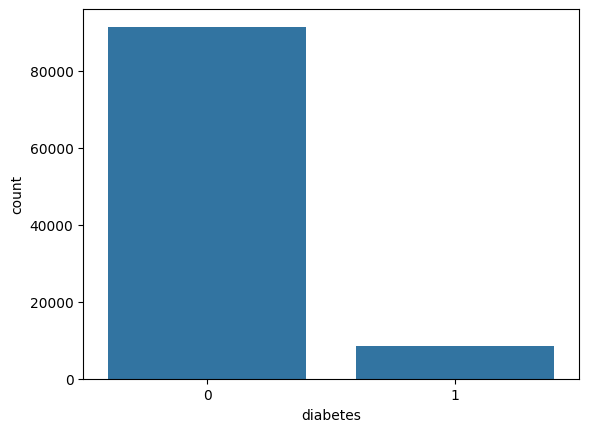

In [95]:
df.isnull().sum()
df.describe()
df['diabetes'].value_counts()
sns.countplot(x = 'diabetes', data = df)
df.duplicated().sum()
df.drop_duplicates(inplace = True)

---
## 🛠️ Step 4 — Data Preprocessing

ML models need **numbers**, not text. We also split data and scale it.

1. **Encode** text columns → numbers  
2. **Split** into Features `X` and Target `y`  
3. **Train-Test Split** — 80% train, 20% test  
4. **Scale** features so all values are on a similar range

In [96]:
df['gender'].nunique()
df['smoking_history'].nunique()
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [97]:
# Encode text columns
cat_cols = df.select_dtypes(include = 'object')
cat_cols

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cat_cols:
  df[col] = le.fit_transform(df[col])
df


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,0,24.60,4.8,145,0
99996,0,2.0,0,0,0,17.37,6.5,100,0
99997,1,66.0,0,0,3,27.83,5.7,155,0
99998,0,24.0,0,0,4,35.42,4.0,100,0


In [98]:
# Split X and Y
X = df.drop('diabetes', axis = 1)
y = df['diabetes']



---
## 🤖 Step 5 — Train Logistic Regression

**Logistic Regression** is the simplest and most interpretable classification model.

- Despite its name, it is used for **classification** (not regression)
- It predicts the **probability** of a patient having diabetes (0 or 1)
- Always a great starting point for any binary classification problem

---
## 📊 Step 6 — Evaluate the Model

We measure performance using:

| Metric | Meaning |
|--------|----------|
| **Accuracy** | % of correct predictions overall |
| **Precision** | Of all predicted diabetic, how many truly are? |
| **Recall** | Of all actual diabetic patients, how many did we catch? |
| **F1-Score** | Balance between Precision and Recall |

> 🏥 In medical problems, **Recall** matters most — missing a diabetic patient is dangerous!

---
## 🔮 Step 7 — Predict on New Patient Data

Let's test our model on a **manually entered patient** to see it in action.

> ✏️ Try changing the values below and re-run the cell to see different predictions!

---
## ✅ Summary

| Step | What We Did |
|------|-------------|
| Load Data | 100,000 rows, 9 columns |
| EDA | Checked nulls, stats, class balance, correlations |
| Preprocessing | Label encoding, 80/20 split, StandardScaler |
| Model | Logistic Regression |
| Evaluation | Accuracy, Classification Report, Confusion Matrix |
| Prediction | Predicted diabetes for a new patient |

### 🚀 Next Steps
- Try **Random Forest** or **XGBoost** for potentially higher accuracy  
- Handle class imbalance using **SMOTE**  
- Tune the model with **GridSearchCV**  
- Build a simple web app using **Streamlit**

> 🎉 You completed a full ML project — this is the same workflow used in the real world!